In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from cycler import cycler

# custom_cycler = cycler(color=[ "#007191","#f47a00","#d31f11","#62c8d3" ]) 
custom_cycler = cycler(color=[ "#4a2377","#8cc5e3","#f55f74","#0d7d87" ])
from plot_utils import *

In [3]:
root_dir='./csvout/Bag-of-trick-ResNet18/'
iter_num = 0
datalist=[]
for file in os.listdir(root_dir):
    if 'enlarge' in file:
        print(file)
        data = pd.read_csv(os.path.join(root_dir,file),encoding='utf-8')
        raw,rand,pro = GR_confusion_compare_matrix(data)
        print('raw-score:{}'.format(adv_f1_score(raw)))
        print('rand-score:{}'.format(adv_f1_score(rand)))
        print('adv-score:{}'.format(adv_f1_score(pro)))
        
        datalist =datalist + [[iter_num]+raw.tolist()+rand.tolist()+pro.tolist()]
        iter_num+=1
        
        print(raw[0]+raw[1],rand[0]+rand[1],pro[0]+pro[1])
        print(raw[0],rand[0],pro[0])

columns = ['step','raw_TP','raw_TN','raw_FP','raw_FN','rand_TP','rand_TN','rand_FP','rand_FN','pro_TP','pro_TN','pro_FP','pro_FN']
agg_data= pd.DataFrame(datalist,columns=columns)

# agg_data.to_csv('./smoothing-enlarge.csv',index=False)
agg_data.to_csv('./smoothing-enlarge.csv',index=False)

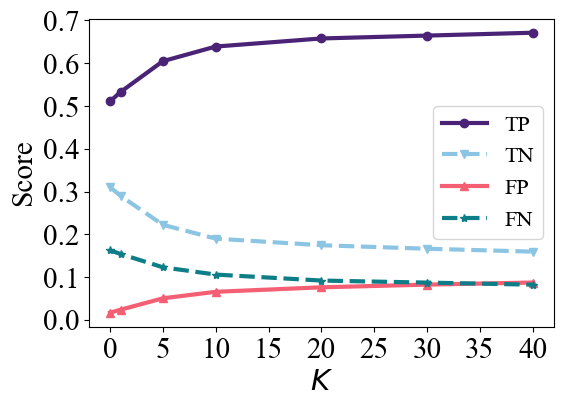

In [14]:
fontsize=21
legedsize=16
data = pd.read_csv('./smoothing-steps.CSV',encoding='utf-8')
plt.figure(figsize=(6,4))
plt.rcParams['axes.prop_cycle'] = custom_cycler
plt.rc('font',family='Times New Roman')

plt.plot(data['Unnamed: 0'],data['TP'],label="TP",marker='o',linewidth=3)
plt.plot(data['Unnamed: 0'],data['TN'],label="TN",linestyle='--',marker='v',linewidth=3)
plt.plot(data['Unnamed: 0'],data['FP'],label="FP",marker='^',linewidth=3)
plt.plot(data['Unnamed: 0'],data['FN'],label="FN",marker='*',linestyle='--',linewidth=3)


plt.yticks(fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.xlabel("$K$",fontsize=21)
plt.ylabel("Score",fontsize=21)
plt.legend(prop={'family' : 'Times New Roman', 'size'   : legedsize})

plt.savefig("./figure/steps.png",bbox_inches = 'tight')

plt.show()


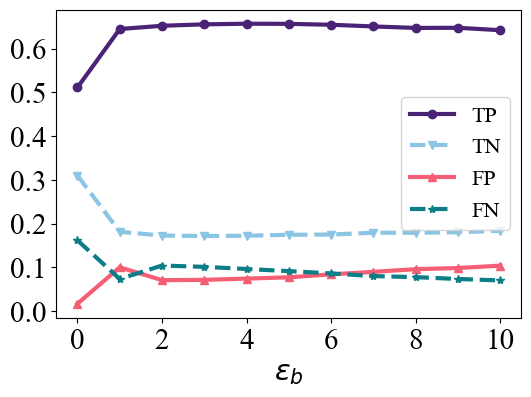

In [16]:
fontsize=21
legedsize=16
data = pd.read_csv('./smoothing-Hbound.CSV',encoding='utf-8')
plt.figure(figsize=(6,4))
plt.rcParams['axes.prop_cycle'] = custom_cycler
plt.rc('font',family='Times New Roman')

plt.plot(data['H bound'],data['TP'],label="TP",marker='o',linewidth=3)
plt.plot(data['H bound'],data['TN'],label="TN",marker='v',linestyle='--',linewidth=3)
plt.plot(data['H bound'],data['FP'],label="FP",marker='^',linewidth=3)
plt.plot(data['H bound'],data['FN'],label="FN",marker='*',linestyle='--',linewidth=3)


plt.yticks(fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.xlabel(r"$\varepsilon_b$",fontsize=21)
plt.legend(prop={'family' : 'Times New Roman', 'size'   : legedsize})

plt.savefig("./figure/varepsilon.png",bbox_inches = 'tight')

plt.show()


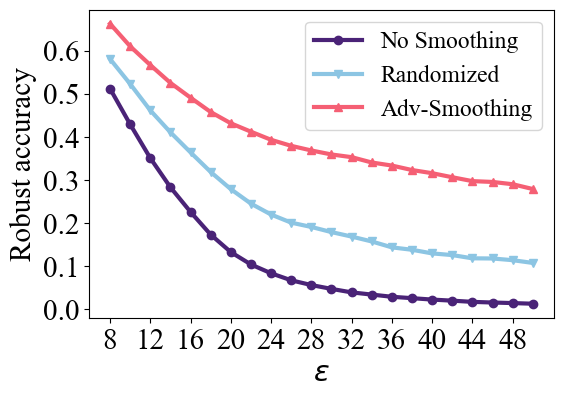

In [ ]:
fontsize=21
legedsize=17
data = pd.read_csv('./smoothing-enlarge.csv',encoding='utf-8')

plt.figure(figsize=(6,4))
plt.rcParams['axes.prop_cycle'] = custom_cycler
plt.rc('font',family='Times New Roman')

plt.plot(data['step'],data['raw_TP'],label="No Smoothing",marker='o',linewidth=3)
plt.plot(data['step'],data['rand_TP'],label="Randomized",marker='v',linewidth=3)
plt.plot(data['step'],data['pro_TP'],label="SelfPure",marker='^',linewidth=3)
# plt.plot(data['H bound'],data['FN'],label="FN",linestyle='--')


plt.yticks(fontsize=fontsize)
plt.xticks(range(8,52,4),fontsize=fontsize)
plt.xlabel(r"$\varepsilon$",fontsize=21)
plt.ylabel(r"Robust accuracy",fontsize=21)
plt.legend(prop={'family' : 'Times New Roman', 'size'   : legedsize})

plt.savefig("./figure/enlarge-cw.png",bbox_inches = 'tight')


plt.show()

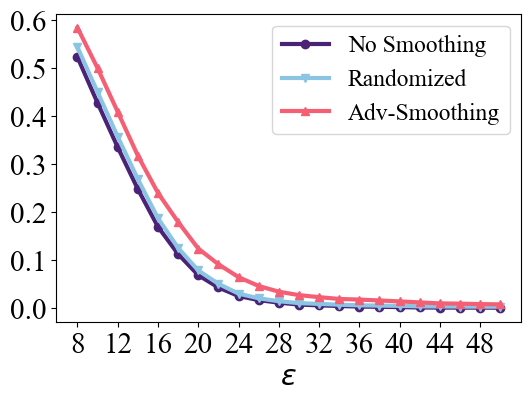

In [ ]:
fontsize=21
legedsize=17
data = pd.read_csv('./smoothing-enlarge-apgd.csv',encoding='utf-8')

plt.figure(figsize=(6,4))
plt.rcParams['axes.prop_cycle'] = custom_cycler
plt.rc('font',family='Times New Roman')

plt.plot(data['step'],data['raw_TP'],label="No Smoothing",marker='o',linewidth=3)
plt.plot(data['step'],data['rand_TP'],label="Randomized",marker='v',linewidth=3)
plt.plot(data['step'],data['pro_TP'],label="SelfPure",marker='^',linewidth=3)
# plt.plot(data['H bound'],data['FN'],label="FN",linestyle='--')


plt.yticks(fontsize=fontsize)
plt.xticks(range(8,52,4),fontsize=fontsize)
plt.xlabel(r"$\varepsilon$",fontsize=21)
# plt.ylabel(r"")
plt.legend(prop={'family' : 'Times New Roman', 'size'   : legedsize})

plt.savefig("./figure/enlarge-apgdce.png",bbox_inches = 'tight')


plt.show()

In [84]:
import csv